In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [2]:
print('Interpretación:')
print()
print('* Se ejecutan los paquetes, esto permite que los paqueten instalados funcionen.')

Interpretación:

* Se ejecutan los paquetes, esto permite que los paqueten instalados funcionen.


In [3]:
pd.set_option('display.width', 900)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
np.set_printoptions(precision=15,suppress=True,linewidth=250)

In [4]:
print('Interpretación:')
print()
print('* Esto más que nada es para que no se me pase a una segunda fila los elementos que son de una fila. (me confunde menos)')

Interpretación:

* Esto más que nada es para que no se me pase a una segunda fila los elementos que son de una fila. (me confunde menos)


In [5]:
data = {
    'Edad': [21, 35, 27, 40, 29, 50, 33, 45, 31, 22],
    'Horas_estudio': [5, 10, 6, 8, 7, 11, 9, 4, 7, 5],
    'Evaluaciones_aprobadas': [2, 5, 3, 4, 3, 6, 5, 2, 4, 3],
    'Participacion_foro': [3, 9, 4, 7, 5, 10, 8, 2, 6, 3],
    'Tareas_entregadas': [4, 10, 6, 8, 6, 12, 9, 3, 7, 4]
}
df = pd.DataFrame(data)

In [6]:
print('Interpretación:')
print()
print('* Se genera data ficticia, correspondiente a 5 tipos de variables (features).')
print('* cada variable tiene 10 observaciones, y las 5 variables son numéricas: "Edad", "Horas_estudio","Evaluaciones_aprobadas","Participacion_foro", y "Tareas_entregadas".')

Interpretación:

* Se genera data ficticia, correspondiente a 5 tipos de variables (features).
* cada variable tiene 10 observaciones, y las 5 variables son numéricas: "Edad", "Horas_estudio","Evaluaciones_aprobadas","Participacion_foro", y "Tareas_entregadas".


In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

nombres_std = [f"{col}_(Estandarizado)" for col in df.columns]
X_scaled_df = pd.DataFrame(X_scaled, columns=nombres_std, index=df.index)
print(X_scaled_df)

   Edad_(Estandarizado)  Horas_estudio_(Estandarizado)  Evaluaciones_aprobadas_(Estandarizado)  Participacion_foro_(Estandarizado)  Tareas_entregadas_(Estandarizado)
0             -1.369969                      -1.008368                               -1.339788                           -1.034642                          -1.059637
1              0.189345                       1.283378                                1.024544                            1.264563                           1.132715
2             -0.701691                      -0.550019                               -0.551677                           -0.651441                          -0.328853
3              0.746243                       0.366679                                0.236433                            0.498161                           0.401931
4             -0.478932                      -0.091670                               -0.551677                           -0.268241                          -0.328853
5   

In [8]:
print('Interpretación:')
print()
print('* Se aplica estandarización directamente sobre -df-, pues, todos los datos son numericos.')

Interpretación:

* Se aplica estandarización directamente sobre -df-, pues, todos los datos son numericos.


In [9]:
print(f'\033[1;31m1. Aplica el algoritmo PCA sobre los datos escalados, reduciendo a 2 o 3 componentes. Visualiza los resultados y reflexiona sobre qué patrones emergen.\033[0m')

1. Aplica el algoritmo PCA sobre los datos escalados, reduciendo a 2 o 3 componentes. Visualiza los resultados y reflexiona sobre qué patrones emergen.


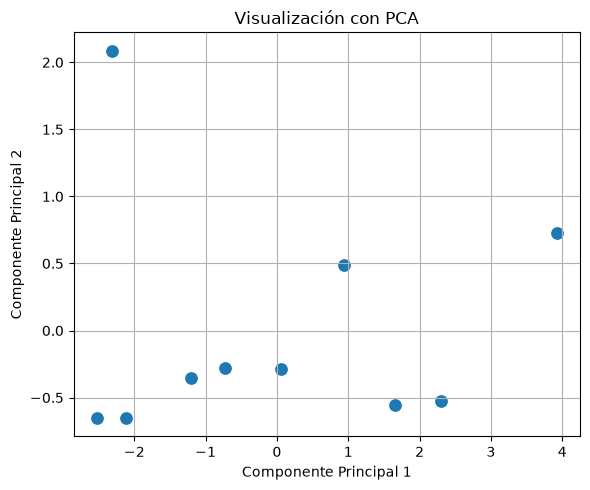

In [10]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_df)

plt.figure(figsize=(6, 5))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], s=100)
plt.title("Visualización con PCA")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.grid(True)
plt.tight_layout()
plt.show()

In [11]:
print('Interpretación:')
print()
print('* Se observa un punto atipico en la esquina superior ezquierda, en el punto (-2.307957,2.086626)')

Interpretación:

* Se observa un punto atipico en la esquina superior ezquierda, en el punto (-2.307957,2.086626)


In [12]:
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

df_ordenado_pca = df.sort_values(by='PCA1')
print(df_ordenado_pca[['Edad', 'Horas_estudio', 'Evaluaciones_aprobadas', 'Participacion_foro', 'Tareas_entregadas', 'PCA1', 'PCA2']])

   Edad  Horas_estudio  Evaluaciones_aprobadas  Participacion_foro  Tareas_entregadas      PCA1      PCA2
0    21              5                       2                   3                  4 -2.527404 -0.648754
7    45              4                       2                   2                  3 -2.307957  2.086626
9    22              5                       3                   3                  4 -2.121421 -0.653141
2    27              6                       3                   4                  6 -1.202393 -0.353793
4    29              7                       3                   5                  6 -0.733799 -0.280273
8    31              7                       4                   6                  7  0.064315 -0.283952
3    40              8                       4                   7                  8  0.940777  0.486845
6    33              9                       5                   8                  9  1.658664 -0.552958
1    35             10                       5

In [1]:
print('Interpretación:')
print()
print('* Se observa que aquel dato atipico posee las siguientes caracteristicas: ')
print('  1. tiene 45 años edad (es de los mayores)')
print('  2. tiene 4 horas de estudio (es el que menos tiene)')
print('  3. tiene 2 evaluaciones aprobadas (es de los de menores)')
print('  4. su participación en foros es de 2 (es el que menos tiene)')
print('  5. tiene 3 tareas entregadas (es el que menos tiene)')
print()
print(' Por lo tanto, esa información es bien representada como un punto alejado de los demás por sus respectivos valores del PCA1 y PCA2 ')

Interpretación:

* Se observa que aquel dato atipico posee las siguientes caracteristicas: 
  1. tiene 45 años edad (es de los mayores)
  2. tiene 4 horas de estudio (es el que menos tiene)
  3. tiene 2 evaluaciones aprobadas (es de los de menores)
  4. su participación en foros es de 2 (es el que menos tiene)
  5. tiene 3 tareas entregadas (es el que menos tiene)

 Por lo tanto, esa información es bien representada como un punto alejado de los demás por sus respectivos valores del PCA1 y PCA2 


In [14]:
print(f'\033[1;31m2. Aplica el algoritmo t-SNE sobre los mismos datos. Ajusta el valor de perplexity y compara los resultados obtenidos con PCA.\033[0m')

2. Aplica el algoritmo t-SNE sobre los mismos datos. Ajusta el valor de perplexity y compara los resultados obtenidos con PCA.


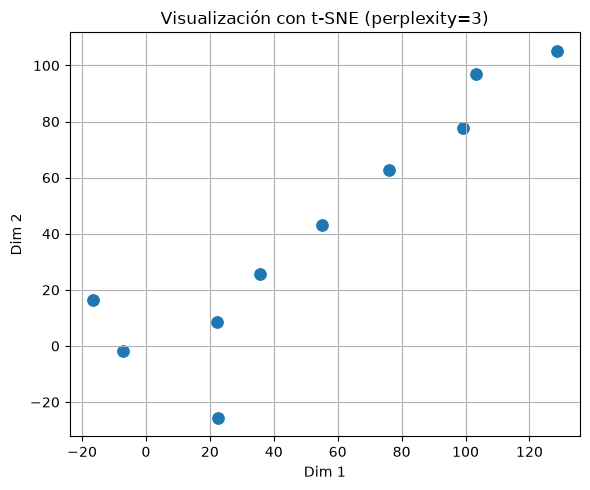

In [15]:
tsne_3 = TSNE(n_components=2, perplexity=3, random_state=42)
X_tsne_3 = tsne_3.fit_transform(X_scaled_df)

plt.figure(figsize=(6, 5))
sns.scatterplot(x=X_tsne_3[:, 0], y=X_tsne_3[:, 1], s=100)
plt.title("Visualización con t-SNE (perplexity=3)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.grid(True)
plt.tight_layout()
plt.show()

In [16]:
print('Interpretación:')
print()
print('* Se observa que la mayoría de datos estan agrupados en el primer cuadrante del plano cartesiano (de forma ascendente),')
print('  y hay dos datos que se alejan un poco de esa forma lineal, el punto (-16.620964,16.340872) y el (22.612144,-25.723267)')

Interpretación:

* Se observa que la mayoría de datos estan agrupados en el primer cuadrante del plano cartesiano (de forma ascendente),
  y hay dos datos que se alejan un poco de esa forma lineal, el punto (-16.620964,16.340872) y el (22.612144,-25.723267)


In [17]:
df['DIM1(perplexity=3)'] = X_tsne_3[:, 0]
df['DIM2(perplexity=3)'] = X_tsne_3[:, 1]

df_ordenado_tsne = df.sort_values(by='DIM1(perplexity=3)')
print(df_ordenado_tsne[['Edad', 'Horas_estudio', 'Evaluaciones_aprobadas', 'Participacion_foro', 'Tareas_entregadas', 'DIM1(perplexity=3)', 'DIM2(perplexity=3)']])


   Edad  Horas_estudio  Evaluaciones_aprobadas  Participacion_foro  Tareas_entregadas  DIM1(perplexity=3)  DIM2(perplexity=3)
0    21              5                       2                   3                  4          -16.620964           16.340872
9    22              5                       3                   3                  4           -7.111497           -1.763117
2    27              6                       3                   4                  6           22.299503            8.500767
7    45              4                       2                   2                  3           22.612144          -25.723267
4    29              7                       3                   5                  6           35.541130           25.625797
8    31              7                       4                   6                  7           55.141727           43.031040
3    40              8                       4                   7                  8           76.163361           62

In [2]:
print('Interpretación:')
print()
print('* En general el dato (-16.620964,16.340872), presenta todos su valores decendidos, tales como: edad, hora estudio, evuaciones aprobadas, participación, y tareas entregadas.')
print('* En general el dato (22.612144,-25.723267), tiene valores mínimos en todas las variables, excepto en la edad, que tiene 45 años (no es el mayor por poco).')
print()
print(' Por lo tanto, esa información es bien representada por DIM1 y DIM2 (perplexity=3). ')

Interpretación:

* En general el dato (-16.620964,16.340872), presenta todos su valores decendidos, tales como: edad, hora estudio, evuaciones aprobadas, participación, y tareas entregadas.
* En general el dato (22.612144,-25.723267), tiene valores mínimos en todas las variables, excepto en la edad, que tiene 45 años (no es el mayor por poco).

 Por lo tanto, esa información es bien representada por DIM1 y DIM2 (perplexity=3). 


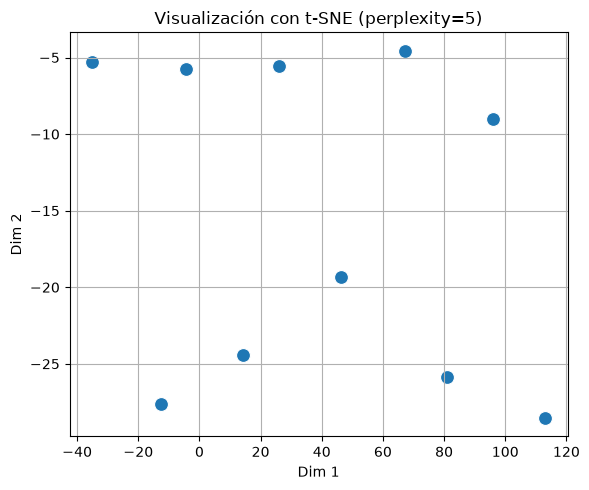

In [19]:
tsne_5 = TSNE(n_components=2, perplexity=5, random_state=42)
X_tsne_5 = tsne_5.fit_transform(X_scaled_df)

plt.figure(figsize=(6, 5))
sns.scatterplot(x=X_tsne_5[:, 0], y=X_tsne_5[:, 1], s=100)
plt.title("Visualización con t-SNE (perplexity=5)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.grid(True)
plt.tight_layout()
plt.show()

In [20]:
df['DIM1(perplexity=5)'] = X_tsne_5[:, 0]
df['DIM2(perplexity=5)'] = X_tsne_5[:, 1]

df_ordenado_tsne = df.sort_values(by='DIM2(perplexity=5)')
print(df_ordenado_tsne[['Edad', 'Horas_estudio', 'Evaluaciones_aprobadas', 'Participacion_foro', 'Tareas_entregadas', 'DIM1(perplexity=5)', 'DIM2(perplexity=5)']])

   Edad  Horas_estudio  Evaluaciones_aprobadas  Participacion_foro  Tareas_entregadas  DIM1(perplexity=5)  DIM2(perplexity=5)
5    50             11                       6                  10                 12          112.968987          -28.545645
0    21              5                       2                   3                  4          -12.621623          -27.630651
6    33              9                       5                   8                  9           80.992851          -25.874878
2    27              6                       3                   4                  6           14.185830          -24.403688
8    31              7                       4                   6                  7           46.256058          -19.310577
1    35             10                       5                   9                 10           96.000862           -9.000851
9    22              5                       3                   3                  4           -4.290615           -5

In [3]:
print('Interpretación:')
print()
print('* Se observa que los datos fueron generados tanto en la parte superior como inferior de la gráfica.')
print('* Se observa que cambió mucho su forma, solo con el hecho de cambiar la cantida de vecinos más cercanos de 3 a 5, muy seguramente por la baja cantidad de datos.')

Interpretación:

* Se observa que los datos fueron generados tanto en la parte superior como inferior de la gráfica.
* Se observa que cambió mucho su forma, solo con el hecho de cambiar la cantida de vecinos más cercanos de 3 a 5, muy seguramente por la baja cantidad de datos.


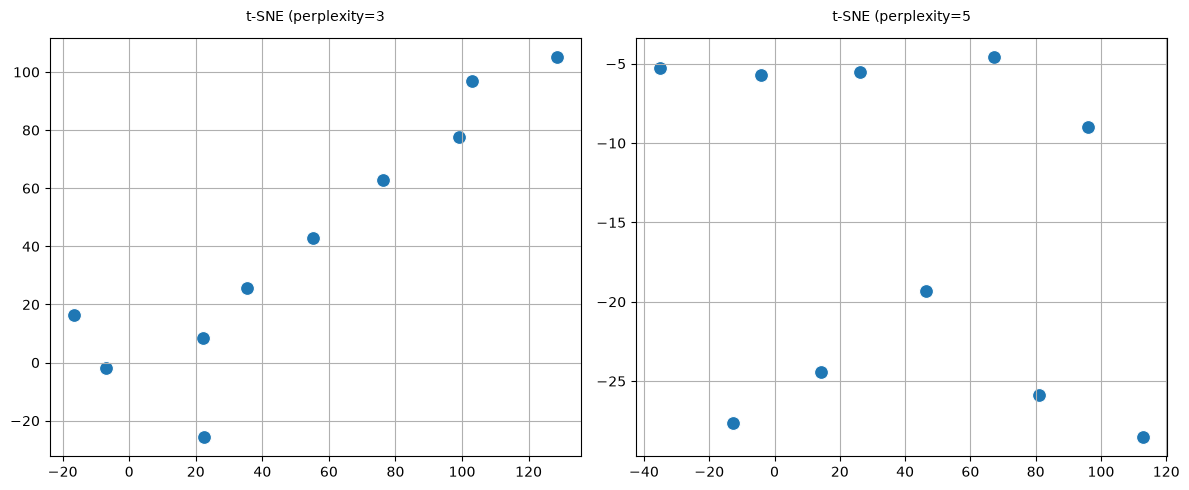

In [22]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(x=X_tsne_3[:, 0], y=X_tsne_3[:, 1], s=100, ax=axs[0])
axs[0].set_title("t-SNE (perplexity=3",fontsize=10, pad=12)
axs[0].grid(True)

sns.scatterplot(x=X_tsne_5[:, 0], y=X_tsne_5[:, 1], s=100, ax=axs[1])
axs[1].set_title("t-SNE (perplexity=5",fontsize=10, pad=12)
axs[1].grid(True)

plt.tight_layout()
plt.show()

In [23]:
print('Interpretación:')
print()
print('* Se observa que con un pequeño cambio en el valor de perplexity, cambia toda la forma de los datos generados.')

Interpretación:

* Se observa que con un pequeño cambio en el valor de perplexity, cambia toda la forma de los datos generados.


In [24]:
print(f'\033[1;31m3. Elabora una tabla comparativa entre PCA y t-SNE incluyendo: tipo de técnica, ventajas, desventajas y casos recomendados de uso.\033[0m')

3. Elabora una tabla comparativa entre PCA y t-SNE incluyendo: tipo de técnica, ventajas, desventajas y casos recomendados de uso.


In [25]:
from tabulate import tabulate

data = [
    ["Tipo de técnica",
     "Es una técnica de reducción dimensional lineal que transforma los datos a un "
     "nuevo sistema de coordenadas donde los ejes (componentes principales) capturan "
     "la máxima varianza posible. Es útil cuando las relaciones entre variables son "
     "lineales y existe redundancia en los datos.",
     "Es un algoritmo no lineal orientado principalmente a la visualización de datos"
     " en espacios de muy alta dimensión. Funciona preservando la probabilidad de cercanía"
     " entre puntos al mapearlos a un espacio de menor dimensión (usualmente 2D)."],

    ["Ventajas",
     "Reducción efectiva de la dimensionalidad con mínima pérdida de información; "
     "Mejora la eficiencia de modelos posteriores; "
     "Fácil de interpretar si se analizan las cargas de los componentes.",
     "Excelente para representar estructuras no lineales; "
     "Facilita la detección visual de patrones, grupos o outliers."],

    ["Desventajas",
     "Solo captura relaciones lineales; "
     "Las nuevas variables (componentes) pueden ser menos interpretables; "
     "Sensible a la escala de los datos. ",
     "No es interpretable ni útil como paso previo a modelos supervisados; "
     "No conserva proporciones ni distancias globales; "
     "Requiere ajuste fino de hiperparámetros (perplejidad, tasa de aprendizaje)."],

    ["Casos recomendados de uso",
     "Visualización exploratoria en 2D o 3D; "
     "Preprocesamiento para modelos supervisados; "
     "Eliminación de colinealidad entre atributos.",
     "Visualización de agrupamientos naturales (clusters); "
     "Análisis exploratorio de datos de sensores, imágenes o texto; "
     "Comprensión de resultados de embeddings de redes neuronales."]
]
headers = ["Criterio", "PCA", "t-SNE"]

tabla = tabulate(data,headers=headers,tablefmt="grid",maxcolwidths=[18, 40, 40])
print(tabla)

+--------------------+------------------------------------------+------------------------------------------+
| Criterio           | PCA                                      | t-SNE                                    |
+====================+==========================================+==========================================+
| Tipo de técnica    | Es una técnica de reducción dimensional  | Es un algoritmo no lineal orientado      |
|                    | lineal que transforma los datos a un     | principalmente a la visualización de     |
|                    | nuevo sistema de coordenadas donde los   | datos en espacios de muy alta dimensión. |
|                    | ejes (componentes principales) capturan  | Funciona preservando la probabilidad de  |
|                    | la máxima varianza posible. Es útil      | cercanía entre puntos al mapearlos a un  |
|                    | cuando las relaciones entre variables    | espacio de menor dimensión (usualmente   |
|                  

In [26]:
print(f'\033[1;31m4. Justifica con base técnica cuál de las dos técnicas aplicarías en la preparación de un modelo de aprendizaje de máquina y por qué.\033[0m')

4. Justifica con base técnica cuál de las dos técnicas aplicarías en la preparación de un modelo de aprendizaje de máquina y por qué.


In [4]:
print('Aplicaría PCA por los siguientes motivos:')
print()
print('1. PCA se puede aplicar posteriormente a datos nuevos (con ayuda de los autovectores), cosa que t-sne no puede, porque optimiza directamente las coordenadas de los puntos de entrada.')
print()
print('2. PCA es reproducible, pues, siempre produce exactamente el mismo resultado cuando se le da el mismo conjunto de datos, cosa que t-sne no puede, porque ')
print('   es estocastico (se le podría cambiar la semilla y que cambien todos los resultados).')
print()
print('3. PCA tiene una complejidad computacional baja, y escala eficientemente a dataset grandes; mientras que, t-sne no se debería aplicar a datasets ')
print('   extremadamente grandes porque su crecimiento es cuadratico.')
print()
print(' Entonces, si quiero dar una respuesta contextualizada a la empresa de análisis educacional, me sirve más PCA, porque puedo interpretar hasta cierto punto los valores de PCA,')
print(' y posteriormente, profundizar aplicando algun de los modelo predictivo.')

Aplicaría PCA por los siguientes motivos:

1. PCA se puede aplicar posteriormente a datos nuevos (con ayuda de los autovectores), cosa que t-sne no puede, porque optimiza directamente las coordenadas de los puntos de entrada.

2. PCA es reproducible, pues, siempre produce exactamente el mismo resultado cuando se le da el mismo conjunto de datos, cosa que t-sne no puede, porque 
   es estocastico (se le podría cambiar la semilla y que cambien todos los resultados).

3. PCA tiene una complejidad computacional baja, y escala eficientemente a dataset grandes; mientras que, t-sne no se debería aplicar a datasets 
   extremadamente grandes porque su crecimiento es cuadratico.

 Entonces, si quiero dar una respuesta contextualizada a la empresa de análisis educacional, me sirve más PCA, porque puedo interpretar hasta cierto punto los valores de PCA,
 y posteriormente, profundizar aplicando algun de los modelo predictivo.
